In [1]:
# Imports and settings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Union, List, Tuple, Dict, Any
from scipy import stats

# Make plots look nice
sns.set(style="whitegrid", palette="muted", context="notebook")
plt.rcParams['figure.dpi'] = 110

In [2]:
# Data standardization functions
def clean_column_name(name: str) -> str:
    """Clean a single column name: strip, lower, replace spaces and punctuation with underscores."""
    if not isinstance(name, str):
        name = str(name)
    name = name.strip().lower()
    # replace spaces and common punctuation with underscore
    allowed = []
    cleaned = []
    for ch in name:
        if ch.isalnum():
            cleaned.append(ch)
        else:
            cleaned.append("_")
    # collapse multiple underscores
    cleaned_name = "".join(cleaned)
    cleaned_name = "_".join([p for p in cleaned_name.split("_") if p])
    return cleaned_name

def infer_and_convert_dtypes(df: pd.DataFrame, date_try_format: bool = True) -> pd.DataFrame:
    """
    Attempt to convert columns to the appropriate dtype:
    - Convert numeric-like columns to numeric (coerce errors -> NaN)
    - Attempt to parse datetime for columns with many parseable values
    """
    df = df.copy()
    for col in df.columns:
        series = df[col]
        # attempt numeric conversion if many values look numeric
        # Check proportion of values convertible to float
        sample = series.dropna().astype(str)
        if len(sample) > 0:
            convertible = sample.str.replace(r"[,\s]", "", regex=True).str.match(r"^-?\d+(\.\d+)?$").sum()
            if convertible / len(sample) > 0.6:
                df[col] = pd.to_numeric(series.astype(str).str.replace(r"[,\s]", "", regex=True), errors="coerce")
                continue
        # attempt datetime parsing if many parseable
        if date_try_format and len(sample) > 0:
            try:
                parsed = pd.to_datetime(series, errors="coerce", infer_datetime_format=True)
                # If a good fraction parsed to timestamps, accept
                if parsed.notna().sum() / max(1, len(parsed)) > 0.6:
                    df[col] = parsed
            except Exception:
                pass
    return df

def standardize_dataframe(df: pd.DataFrame,
                          drop_threshold: float = 0.5,
                          fill_numeric: str = "median",
                          fill_categorical: str = "mode") -> pd.DataFrame:
    """
    Standardize formatting of a DataFrame:
    - Clean column names
    - Trim string values
    - Convert numeric-like columns
    - Parse dates when possible
    - Handle missing values: drop columns with too many missing values (default 50%)
      and impute remaining numerics with median (or mean) and categoricals with mode (or 'unknown').
    Returns a cleaned copy of the DataFrame.
    """
    df = df.copy()
    # Clean column names
    df.columns = [clean_column_name(c) for c in df.columns]

    # Trim whitespace for object columns
    obj_cols = df.select_dtypes(include=["object"]).columns
    for col in obj_cols:
        df[col] = df[col].astype(str).str.strip().replace({"nan": pd.NA})

    # Infer dtypes and convert numeric & dates where appropriate
    df = infer_and_convert_dtypes(df)

    # Drop columns with too many missing values
    missing_frac = df.isna().mean()
    cols_to_drop = missing_frac[missing_frac > drop_threshold].index.tolist()
    if cols_to_drop:
        df.drop(columns=cols_to_drop, inplace=True)

    # Impute missing values
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            if fill_numeric == "median":
                replacement = df[col].median()
            elif fill_numeric == "mean":
                replacement = df[col].mean()
            else:
                replacement = fill_numeric  # could be a scalar
            df[col] = df[col].fillna(replacement)
        else:
            if fill_categorical == "mode":
                modes = df[col].mode()
                replacement = modes.iloc[0] if not modes.empty else "unknown"
            else:
                replacement = fill_categorical
            df[col] = df[col].fillna(replacement)

    # Final pass: convert booleans where obvious
    for col in df.columns:
        if df[col].dropna().isin([0, 1, True, False]).all():
            df[col] = df[col].astype(int)

    return df

In [5]:
# Calculation functions (6 descriptive + 3 additional = 9)
def calc_mean(series: pd.Series, ddof: int = 0) -> float:
    """Return the mean of a pandas Series (skip NA)."""
    return float(series.mean(skipna=True))

def calc_median(series: pd.Series) -> float:
    """Return the median of a pandas Series (skip NA)."""
    return float(series.median(skipna=True))

def calc_mode(series: pd.Series) -> List[Any]:
    """Return the mode(s) of a Series as a list (handles multimodal)."""
    modes = series.mode(dropna=True)
    return modes.tolist()

def calc_range(series: pd.Series) -> float:
    """Return the range (max - min) of a Series (skip NA)."""
    series = series.dropna()
    if series.empty:
        return float("nan")
    return float(series.max() - series.min())

def calc_variance(series: pd.Series, ddof: int = 1) -> float:
    """Return the sample variance (ddof=1 by default)."""
    return float(series.var(ddof=ddof, skipna=True))

def calc_std_dev(series: pd.Series, ddof: int = 1) -> float:
    """Return the standard deviation (sample, ddof=1 by default)."""
    return float(series.std(ddof=ddof, skipna=True))

# Additional calculations (provide deeper insights)
def calc_iqr(series: pd.Series) -> float:
    """Return the interquartile range (Q3 - Q1)."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return float(q3 - q1)

def calc_coefficient_of_variation(series: pd.Series, ddof: int = 1) -> float:
    """
    Coefficient of Variation = (std / mean)
    Useful to compare relative variability across variables with different units or means.
    """
    mean = series.mean(skipna=True)
    std = series.std(ddof=ddof, skipna=True)
    if mean == 0 or pd.isna(mean) or pd.isna(std):
        return float("nan")
    return float(std / mean)

def calc_skewness(series: pd.Series) -> float:
    """Return the sample skewness using pandas (Fisher-Pearson)."""
    return float(series.skew(skipna=True))

def calc_z_scores(series: pd.Series) -> pd.Series:
    """Return z-scores (standard scores) for a numeric Series."""
    return (series - series.mean()) / series.std(ddof=0)

# A convenience function to get a descriptive summary using the above functions
def descriptive_summary(df: pd.DataFrame, numeric_only: bool = True) -> pd.DataFrame:
    """
    Compute a table of descriptive statistics for each numeric column in df.
    Returns a DataFrame with rows = statistics and columns = original numeric columns.
    """
    if numeric_only:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()
    else:
        cols = df.columns.tolist()

    records = {}
    for c in cols:
        s = df[c].dropna()
        records[c] = {
            "count": int(s.count()),
            "mean": calc_mean(s),
            "median": calc_median(s),
            "mode": calc_mode(s),
            "range": calc_range(s),
            "variance": calc_variance(s),
            "std_dev": calc_std_dev(s),
            "iqr": calc_iqr(s),
            "coef_var": calc_coefficient_of_variation(s),
            "skewness": calc_skewness(s)
        }
    return pd.DataFrame.from_dict(records, orient="columns").T

In [ ]:
from pathlib import Path

# Generalized CSV path: looks in the same directory as the notebook
# This works on any device as long as the notebook and CSV file are in the same folder
csv_filename = "Occupational_Employment_and_Wage_Statistics.csv"
csv_path = Path(csv_filename)

# Verify the file exists
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find '{csv_filename}'. Please ensure it's in the same directory as this notebook.")

df_raw = pd.read_csv(csv_path)
df = standardize_dataframe(df_raw)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()


/var/folders/k9/h_jdxn6j1tlf35hyqh225gq80000gn/T/ipykernel_28815/3371080060.py:40: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_datetime(series, errors="coerce", infer_datetime_format=True)
/var/folders/k9/h_jdxn6j1tlf35hyqh225gq80000gn/T/ipykernel_28815/3371080060.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(series, errors="coerce", infer_datetime_format=True)
/var/folders/k9/h_jdxn6j1tlf35hyqh225gq80000gn/T/ipykernel_28815/3371080060.py:40: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default

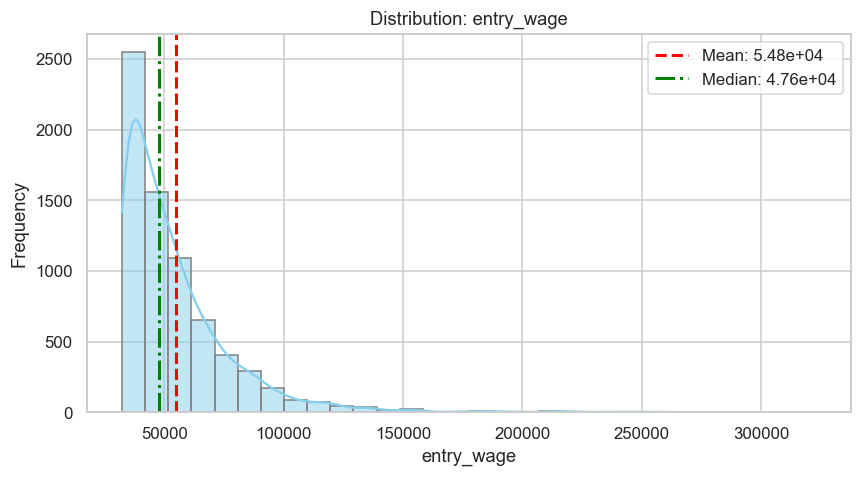

In [18]:
# Visualization 1 (Descriptive stat #1)
# Histogram with mean and median lines for a chosen numeric column
def plot_hist_with_mean_median(series: pd.Series, bins: int = 30, title: str = None):
    """
    Plot a histogram of series with vertical lines for mean and median.
    """
    plt.figure(figsize=(8, 4.5))
    sns.histplot(series.dropna(), bins=bins, kde=True, color="skyblue", edgecolor="gray")
    mean_val = calc_mean(series)
    median_val = calc_median(series)
    plt.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.3g}")
    plt.axvline(median_val, color="green", linestyle="-.", linewidth=2, label=f"Median: {median_val:.3g}")
    plt.title(title or f"Distribution: {series.name}")
    plt.xlabel(series.name)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_hist_with_mean_median(df[numeric_cols[5]])

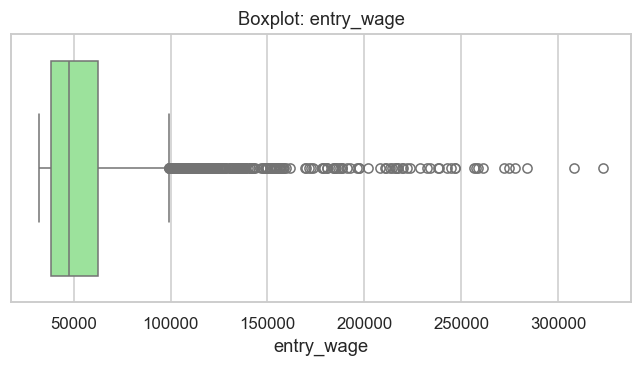

In [16]:
# Visualization 2 (Descriptive stat #2)
# Boxplot to visualize median, IQR, and outliers
def plot_boxplot(series: pd.Series, title: str = None):
    plt.figure(figsize=(6, 3.5))
    sns.boxplot(x=series.dropna(), color="lightgreen")
    plt.title(title or f"Boxplot: {series.name}")
    plt.xlabel(series.name)
    plt.tight_layout()
    plt.show()

plot_boxplot(df[numeric_cols[5]])

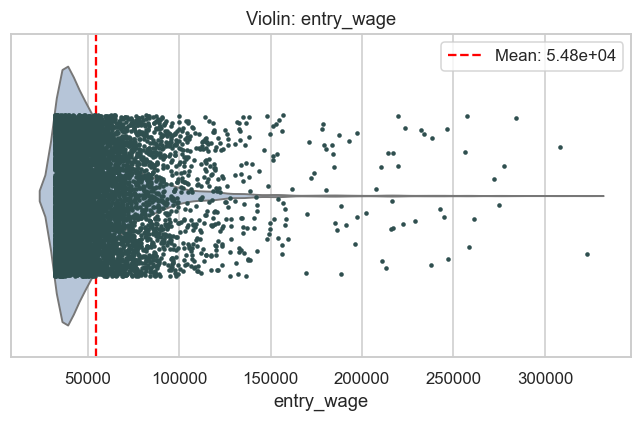

In [19]:
# Visualization 3 (Descriptive stat #3)
# Violin + swarm to show distribution & summary (useful to see multimodality)
def plot_violin_with_points(series: pd.Series, title: str = None):
    plt.figure(figsize=(6, 4))
    sns.violinplot(x=series.dropna(), inner=None, color="lightsteelblue")
    sns.stripplot(x=series.dropna(), color="darkslategray", size=3, jitter=0.25)
    mean_val = calc_mean(series)
    plt.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.3g}")
    plt.title(title or f"Violin: {series.name}")
    plt.xlabel(series.name)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_violin_with_points(df[numeric_cols[5]])

/var/folders/k9/h_jdxn6j1tlf35hyqh225gq80000gn/T/ipykernel_28815/4156272857.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coef_df.values, y=coef_df.index, palette="viridis")


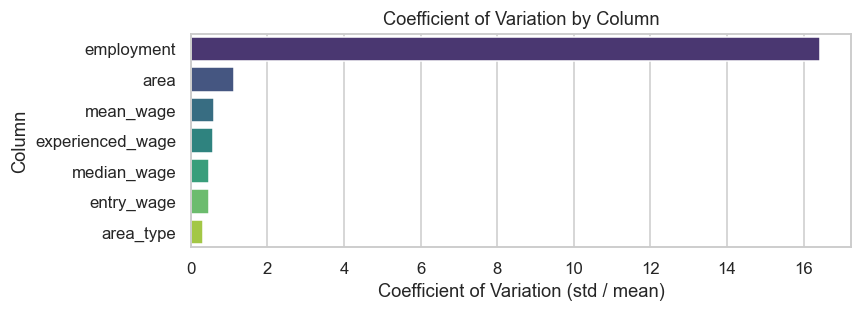

In [21]:
# Visualization 4 (Additional calc #1)
# Bar chart of Coefficient of Variation across numeric columns
def plot_coef_var_bar(df: pd.DataFrame, title: str = "Coefficient of Variation by Column"):
    numeric = df.select_dtypes(include=[np.number])
    coef_vars = {col: calc_coefficient_of_variation(numeric[col]) for col in numeric.columns}
    coef_df = pd.Series(coef_vars).sort_values(ascending=False)
    plt.figure(figsize=(8, max(3, 0.3 * len(coef_df))))
    sns.barplot(x=coef_df.values, y=coef_df.index, palette="viridis")
    plt.xlabel("Coefficient of Variation (std / mean)")
    plt.ylabel("Column")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_coef_var_bar(df)

/var/folders/k9/h_jdxn6j1tlf35hyqh225gq80000gn/T/ipykernel_28815/4085848839.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skew_ser.values, y=skew_ser.index, palette=palette)


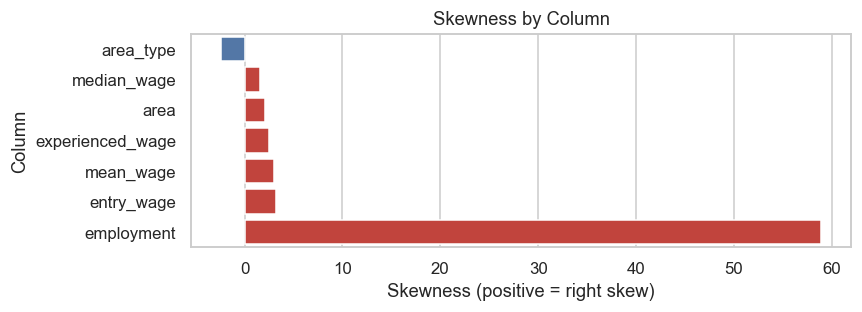

In [23]:
# Visualization 5 (Additional calc #2)
# Bar chart of skewness across numeric columns
def plot_skewness_bar(df: pd.DataFrame, title: str = "Skewness by Column"):
    numeric = df.select_dtypes(include=[np.number])
    skew_vals = {col: calc_skewness(numeric[col]) for col in numeric.columns}
    skew_ser = pd.Series(skew_vals).sort_values()
    plt.figure(figsize=(8, max(3, 0.3 * len(skew_ser))))
    palette = ["#d73027" if v > 0 else "#4575b4" for v in skew_ser.values]
    sns.barplot(x=skew_ser.values, y=skew_ser.index, palette=palette)
    plt.xlabel("Skewness (positive = right skew)")
    plt.ylabel("Column")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_skewness_bar(df)

/var/folders/k9/h_jdxn6j1tlf35hyqh225gq80000gn/T/ipykernel_28815/166477199.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(x=res_df["proportion"].values, y=res_df.index, palette="rocket_r")


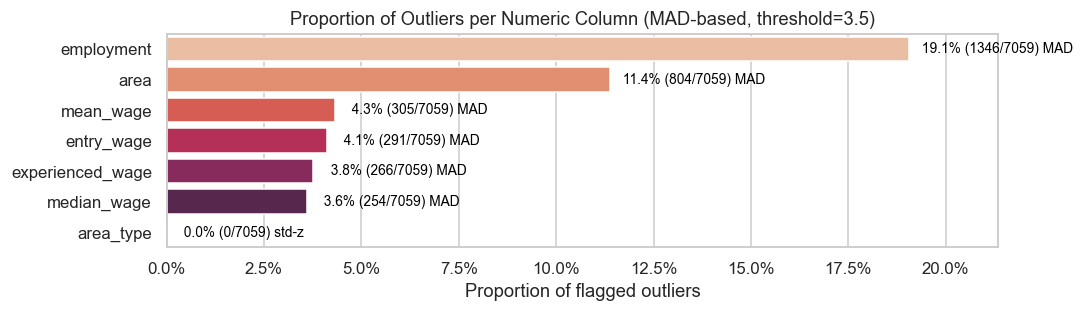

In [25]:
# Visualization 6 (Additional calc #3)
def plot_outlier_proportion_heatmap(df: pd.DataFrame,
                                    threshold: float = 3.5,
                                    fallback_z_threshold: float = 3.0,
                                    title: str | None = None):
    """
    Robust outlier proportion per numeric column using the modified z-score (MAD-based).

    - Uses the modified z-score: modified_z = 0.6745 * (x - median) / MAD
      Common rule-of-thumb: |modified_z| > 3.5 indicates an outlier.
    - If MAD == 0 for a column (no dispersion), falls back to standard z-score
      using mean/std and the fallback_z_threshold (default 3.0).
    - Produces a horizontal bar chart sorted by proportion of outliers, with
      annotations showing percentage and counts.

    Note: This function replaces the previous heatmap-based visualization with
    a clearer, annotated bar chart for robust outlier detection.
    """
    numeric = df.select_dtypes(include=[np.number])
    if numeric.empty:
        raise ValueError("No numeric columns found in the DataFrame.")

    results = []
    for col in numeric.columns:
        s = numeric[col].dropna()
        n = len(s)
        if n == 0:
            results.append((col, 0.0, 0, n, "empty"))
            continue

        med = s.median()
        mad_raw = float(np.median(np.abs(s - med)))

        if mad_raw > 0:
            # modified z-score
            mod_z = 0.6745 * (s - med) / mad_raw
            outliers = mod_z.abs() > threshold
            count = int(outliers.sum())
            prop = count / n
            method = "MAD"
        else:
            # fallback to standard z-score (less robust)
            std = s.std(ddof=0)
            if std > 0:
                z = (s - s.mean()) / std
                outliers = z.abs() > fallback_z_threshold
                count = int(outliers.sum())
                prop = count / n
                method = "std-z"
            else:
                prop = 0.0
                count = 0
                method = "no-disp"

        results.append((col, prop, count, n, method))

    # Build a DataFrame sorted by proportion descending
    res_df = pd.DataFrame(results, columns=["column", "proportion", "count", "n", "method"])
    res_df = res_df.set_index("column").sort_values("proportion", ascending=False)

    # Plotting: horizontal bar chart with annotations
    plt.figure(figsize=(10, max(3, 0.35 * len(res_df))))
    bar = sns.barplot(x=res_df["proportion"].values, y=res_df.index, palette="rocket_r")

    # Annotate bars with percentage and counts
    for i, (prop, row) in enumerate(zip(res_df["proportion"].values, res_df.itertuples())):
        pct = f"{prop * 100:5.1f}%"
        count_info = f"({row.count}/{row.n})"
        method_info = f"{row.method}"
        bar.annotate(f"{pct} {count_info} {method_info}",
                     xy=(prop, i),
                     xytext=(6, 0),
                     textcoords="offset points",
                     va="center",
                     fontsize=9,
                     color="black")

    # Configure axes and formatting
    max_prop = res_df["proportion"].max() if not res_df.empty else 0
    plt.xlim(0, min(1.0, max(max_prop * 1.12, 0.1)))
    plt.xlabel("Proportion of flagged outliers")
    plt.ylabel("")
    plt.title(title or f"Proportion of Outliers per Numeric Column (MAD-based, threshold={threshold})")
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1.0))
    plt.tight_layout()
    plt.show()


plot_outlier_proportion_heatmap(df, threshold=3.5)